# In Depth: Linear Regression

linear regression models are a great start for regression tasks.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

## Simple Linear Regression

The most familiar linear regression is a straight-line fit:
$$y = ax + b$$

where $a$ is commonly known as the slope, and $b$ as the $y$-intercept.

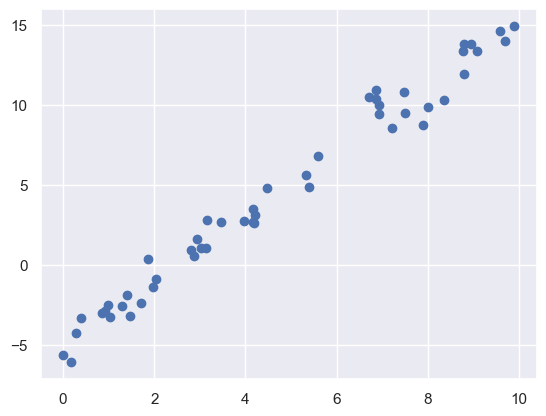

In [4]:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = 2 * x - 5 + rng.randn(50)
plt.scatter(x,y);

We can use the `LinearRegression` class from the scikit learn library to fit a straight line on the data

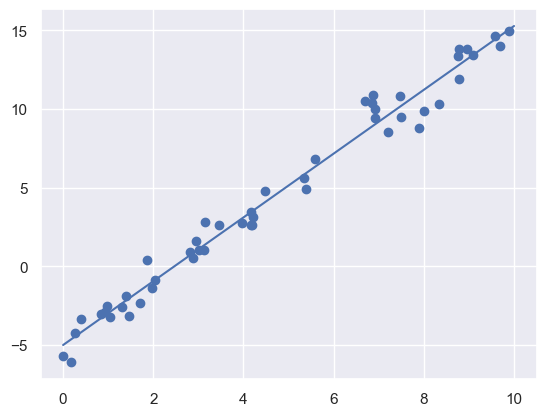

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=True)
X = x[:, np.newaxis] #Features matrix

model.fit(X,y)

xfit = np.linspace(0,10,1000)
yfit = model.predict(xfit[:, np.newaxis])

plt.scatter(x,y)
plt.plot(xfit, yfit);

Coefficients $a$ and $b$ are saved in attributes `.coef_` and `.intercept_`, respectively.

In [8]:
print('Slope (a):    ', model.coef_[0])
print('Intercept (b):', model.intercept_)

Slope (a):     2.027208810360695
Intercept (b): -4.998577085553202


## Multiple Linear Regression

Another regression technique is multiple linear regression:

$$y = a_0 + a_1 x_1 + a_2 x_2 + \cdots + a_n x_n$$

Where $n$ is the number of features in the features matrix. This is equivalent to fitting a plane if $n=3$ or a hyperplane if $n\geq 4$

We use Scikit-Learns's `LinearRegression` for multiple linear regression as well.

In [11]:
X = 10 * rng.rand(100,3) #Features matrix with 3 features
y = 0.5 * np.dot(X, [1.5,-2.,1.])

model.fit(X,y)
print(model.intercept_)
print(model.coef_)

-3.1086244689504383e-15
[ 0.75 -1.    0.5 ]


## Basis Function Regression

We can still use a linear regression model to model nonlinear relationships by transforming the data according to *basis functions*.

Suppose the relationship between the target `y` and a single feature `x` is nonlinear. We take our multiple linear regression model $$y = a_0 + a_1x_1 + \cdots +a_nx_n$$ and build $x_1, x_2, \cdots, x_n$ from $x$ with transformations: That is, we let $x_i = f_i(x)$ where each $f_i$ is some function.

### Example: Polynomial basis functions
In this case, $f_i(x)=x^i$. So, we model the nonlinear relationship of `x` and `y` with
\begin{align*}
    y &= a_0 + a_1 f_1(x) + a_2 f_2(x) + \cdots + a_n f_n(x) \\
    y &= a_0 + a_1 x + a_2 x^2 + \cdots + a_n x^n
\end{align*}

Take note that this is still multiple linear regression! Instead of nonlinear regression, we model the one-dimensional nonlinear relationship by projecting it onto higher dimensions using multiple linear regression.

Scikit-learn's `PolynomialFeatures` class can be used to construct our basis functions $x_i=f_i(x)$ for use with multiple linear regression.

In [12]:
from sklearn.preprocessing import PolynomialFeatures
x = np.array([2, 3, 4]) #one dimensional input x

# Construct x, x^2, x^3
poly = PolynomialFeatures(degree=3, include_bias=False)
poly.fit_transform(x[:, None])

array([[ 2.,  4.,  8.],
       [ 3.,  9., 27.],
       [ 4., 16., 64.]])

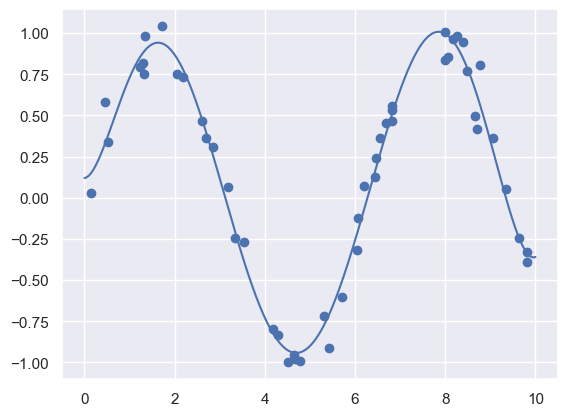

In [73]:
# Demo: Fitting a nonlinear curve with multiple linear regression
# Use a pipeline -- our model will do transformation + curve-fitting
from sklearn.pipeline import Pipeline

# Create model instance - we'll fit a polynomial of degree 7
model = Pipeline([
    ('transform', PolynomialFeatures(degree=7, include_bias=False)),
    ('fit', LinearRegression(fit_intercept=True))
])

# Arrange data
x = 10 * rng.rand(50)
y = np.sin(x) + 0.1 * rng.randn(50)

# Fit model
yfit = model.fit(x[:,np.newaxis],y).predict(xfit[:,np.newaxis])

# Plot
plt.scatter(x,y)
plt.plot(xfit,yfit);

### Example: Gaussian Basis Functions
In this case, our basis functions are Gaussian functions:
$$f_k(x) = \exp\left(-\frac{(x-k)^2}{2\sigma^2}\right)$$

$k$ is the position of the center of the peak, $\sigma$ controls the width of the bell.

Unfortunately, Scikit-Learn does not have a transformer that generates Gaussian Features. But this is a good time to explore Scikit-Learn's `BaseEstimator` and `TransformerMixin` classes for creating our own class of models from scratch!

Using `BaseEstimator` and `TransformMixin` as the parent classes will make our model compatible with Scikit-Learn.

In [75]:
from sklearn.base import BaseEstimator, TransformerMixin

class GaussianFeatures(BaseEstimator, TransformerMixin):
    """Uniformly spaced Gaussian features for one-dimensional input"""

    def __init__(self, N, width_factor=2.0):
        """
        N is the number of Gaussian function
        width_factor is the width of each Gaussian function; default value = 2.0
        """
        self.N = N
        self.width_factor = width_factor

    @staticmethod
    def _gauss_basis(X, centers, width):
        """
        Return the Gaussian features matrix.
        
        X is assumed to be an array with shape (n_samples, 1)
        centers is assumed to be the array containing the centers of the Gaussian functions
        width is assumed to be the width of the Gaussian functions (same width for all)
        """
        # This is a utility function used within the transform function
        arg = (X - centers) / width
        return np.exp(-0.5 * arg**2)

    def fit(self, X, y=None):
        """
        Returns the self fitted to the features matrix X

        X is assumed to contain only one feature, i.e., X.shape == (n_samples, 1)
        """
        # Generate centers of the Gaussians
        self.centers_ = np.linspace(X.min(), X.max(), self.N)

        # Generate width -- one width for all
        self.width_ = self.width_factor * (self.centers_[1] - self.centers_[0])

        return self

    def transform(self, X):
        """
        Returns the Gaussian features matrix based on X.

        X is assumed to be a features matrix with shape (n_samples, 1)
        """
        return self._gauss_basis(X, self.centers_, self.width_)

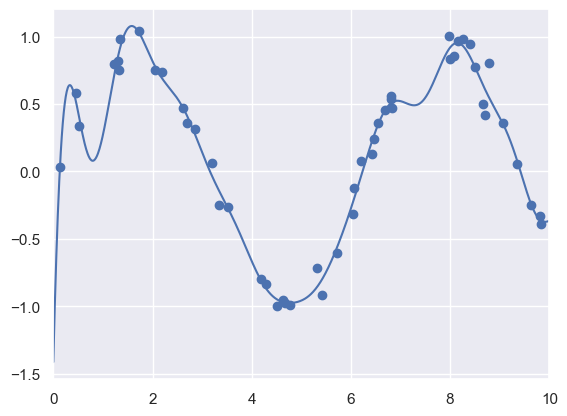

In [115]:
model = Pipeline([
    ('features', GaussianFeatures(20)),
    ('fit', LinearRegression(fit_intercept=True))
])

yfit = model.fit(x[:,np.newaxis], y).predict(xfit[:,np.newaxis])

plt.scatter(x,y)
plt.plot(xfit, yfit)
plt.xlim(0, 10);

## Regularization

Regularization is a set of methods that forces learning to build a less complex model.

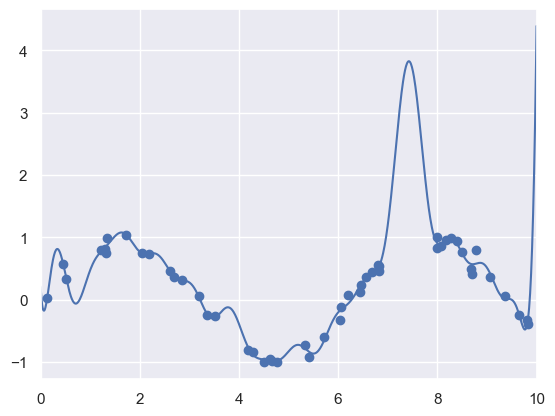

In [116]:
#x,y,xfit as defined earlier
X = x[:,np.newaxis]
Xfit = xfit[:,np.newaxis]
yfit = model.set_params(features__N=30).fit(X,y).predict(Xfit)

plt.scatter(x,y)
plt.plot(xfit,yfit)
plt.xlim(0,10);

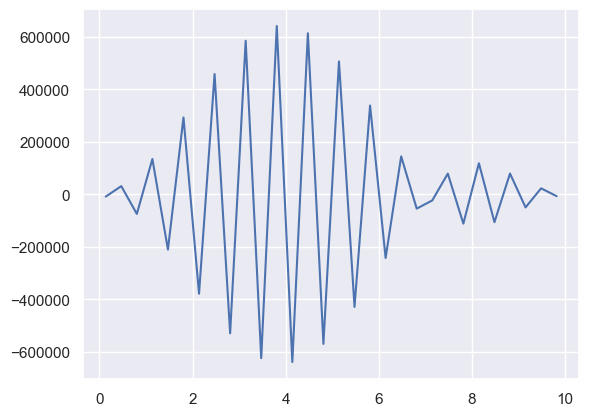

In [117]:
plt.plot(
    model.steps[0][1].centers_,
    model.steps[1][1].coef_
)

In [143]:
def basis_plot(model, title=None):
    fig, ax = plt.subplots(2, sharex=True)
    ax[0].scatter(x,y)

    ax[0].plot(Xfit, yfit)
    ax[0].set(
        xlabel='x',
        ylabel='y',
        ylim=(-1.5,1.5)
    )

    if title:
        ax[0].set_title(title)

    ax[1].plot(
        model.steps[0][1].centers_,
        model.steps[1][1].coef_
    )
    ax[1].set(
        xlabel='basis location',
        ylabel='coefficient',
        xlim=(0,10)
    )

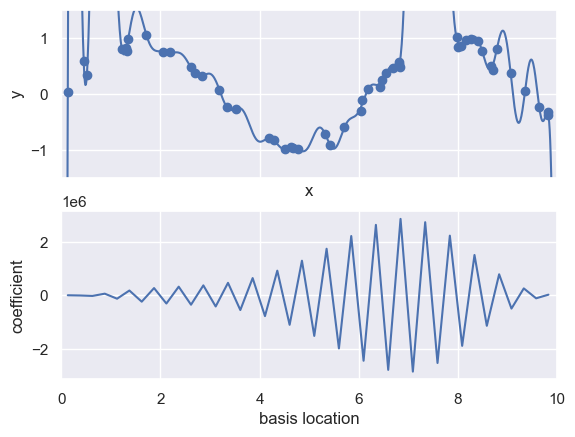

In [119]:
yfit = model.set_params(features__N=40).fit(X,y).predict(Xfit)
basis_plot(model)

With more basis functions, the model tends to overfit the data. It is problematic for a model when coefficients of adjacent basis functions blow up in different directions and cancelling each other out. (I have not fully grasped this idea yet: the relationship between coefficients wildly oscillating and overfitting... but apparently this results in an unstable model)

A way to prevent the coefficients from blowing up is to penalize them: That is, we add a term to the linear regression objective function that is dependent on the coefficients. That way, the coefficients can't blow up! Otherwise, the objective function would not be minimized.

There are two very common forms of regularization: **Ridge regression ($L_2$ regularization)** and **Lasso regularization ($L_1$)**

### Ridge regression ($L_2$ regularization)

Recall that the objective for linear regression is

$$\min_{(w_1,w_2,\dots,w_k),\,b}\,\sum_{i=0}^{n}{(y_i-\hat{y})^2}$$
$$\hat{y} = b + w_1x_1 + w_2x_2 + \cdots + w_kx_k$$

In other words, we choose, as estimators of the actual coefficients, the values of $b,w_1,w_2,\dots,w_k$ that minimize the sum of the squared differences.

The objective for ridge regression penalizes the sum of the squares of the coefficients (2-norm)

$$\min_{(w_1,w_2,\dots,w_k),\,b}\,\left(P + \sum_{i=0}^{n}{(y_i-\hat{y})^2}\right)$$
$$P = \alpha \sum_{i=0}^{k}{w_i^2}$$
$$\hat{y} = b + w_1x_1 + w_2x_2 + \cdots + w_kx_k$$

Here, $\alpha$ is a hyperparameter that controls the importance of the regularization.
- A larger $\alpha$ means the coefficients are penalized more when they get large.
- A smaller $\alpha$ means less regularization.

We can implement this using Scikit-Learn's `Ridge` model.

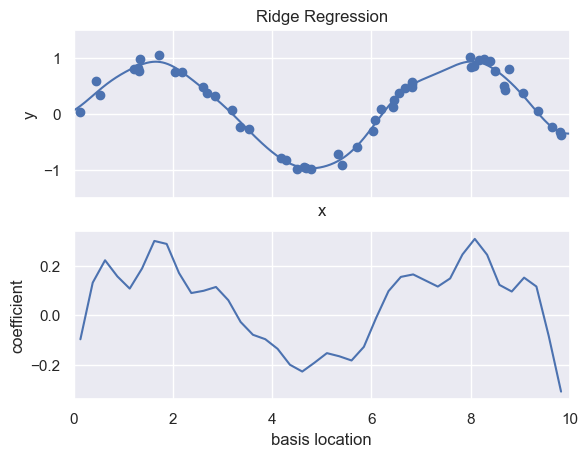

In [124]:
from sklearn.linear_model import Ridge

model = Pipeline([
    ('features', GaussianFeatures(40)),
    ('fit', Ridge(alpha=0.1))
])

yfit = model.fit(X,y).predict(Xfit)
basis_plot(model,title='Ridge Regression')

As we can see, even a small value for alpha reduces the magnitude of the coefficients enough to prevent overfitting.

### Lasso regularization ($L_1$)

Lasso regularization is similar to ridge regression; but, instead of the sum of the squares of the coefficients, the sum of the absolute values is penalized.

$$P = \alpha \sum_{i=0}^{k}{|w_i|}$$

In practice, lasso regularization produces a **sparse model**, one that has most of its parameters equal to zero. So, this type of regularization performs feature selection: decides which features are essential, and which ones are not (they are set to 0).

We can use Lasso regularization with Scikit-Learn's `Lasso` class

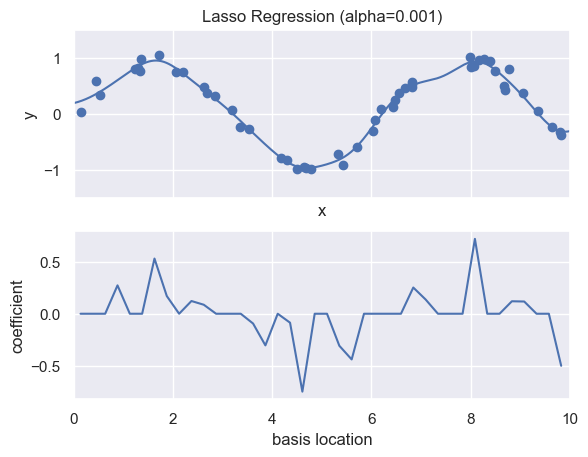

In [137]:
from sklearn.linear_model import Lasso

model = Pipeline([
    ('features', GaussianFeatures(40)),
    ('fit', Lasso(alpha=0.001))
])

yfit = model.fit(X,y).predict(Xfit)
basis_plot(model,title='Lasso Regression (alpha=0.001)')

And as we can see, the model *got that fit oooooon!* However, notice, that some coefficients are set to 0.

Increasing the value of alpha results in more coefficients being set to zero.

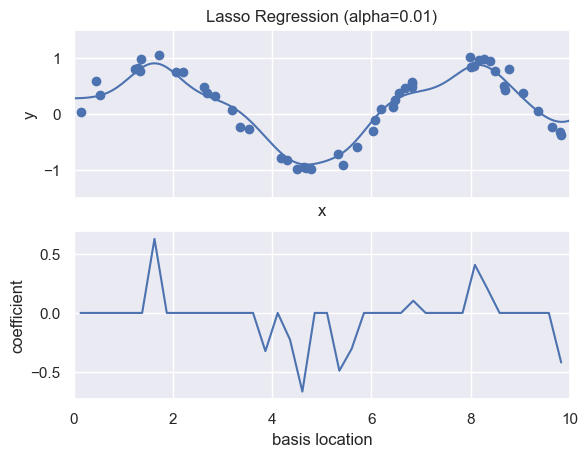

In [142]:
yfit = model.set_params(fit__alpha=0.01).fit(X,y).predict(Xfit)
basis_plot(model,title='Lasso Regression (alpha=0.01)')

- Ridge regression is better if our only goal is to maximize the performance of the model on the holdout set.
- Lasso regularization is useful to increase model explainability.